<a href="https://colab.research.google.com/github/zapatita-27/EstadisticaVerano2026/blob/main/Gym%20membrs/Gym_members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/zapatita-27/EstadisticaVerano2026/refs/heads/main/StudentPerformance/gym_members_exercise_tracking.csv")

df

,Age,Gender,Weight_(kg),Height_(m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration_(hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [2]:
X = df["Session_Duration_(hours)"]
Y = df["Calories_Burned"]

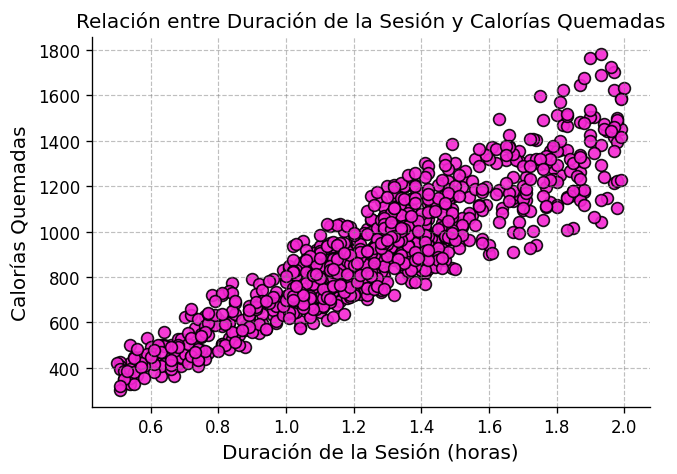

In [3]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Duración de la Sesión (horas)', # etiqueta del eje x (X es Session_Duration_(hours))
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calorías Quemadas', # etiqueta del eje y (Y es Calories_Burned)
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.title('Relación entre Duración de la Sesión y Calorías Quemadas')

plt.show()

El gráfico de disperción muestra una clara tendencia lineal positiva. Conforme aumentan las calorias quemadas, tambien aumenta la duracion de la secion de ejercicio.

In [4]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn:  0.9081
valor_p:  0.0000


El coeficiente de correlación $r=0.9081$ indica una correlación lineal positiva y mas fuerte , sin embargo, se rechaza la hipotesis nula y se concluye que si existe correlacion lineal entre las variables.

In [5]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [6]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.47%


Una vez ajustado el modelo de regresión lienal, se obtiene un coeficiente de determinación de $R^2=0.8247$. Esto significa que, a partir de la duracion de la secion y modelo ajustado, podemos ver que el 82.47% de la variabilidad observada en las calorias quemadas, se trata de un valor alto.

La ecuación de la recta es:

$$
\hat{y}=-1.446459+721.786016X
$$

Este modelo estima que, la calificación base ($X=0$) es de aproximadamente $1.44$. Lo que significa que si un estudiante no estudia, se espera que obtenga un índice de desempeño con ese valor. Mientras que una pendiente de 721.78, indica que por cada hora estudiada se espera un aumento en la calificación de aproximadamente 721.78.


In [7]:
modelo.params


,0
const,-1.446459
Session_Duration_(hours),721.786016


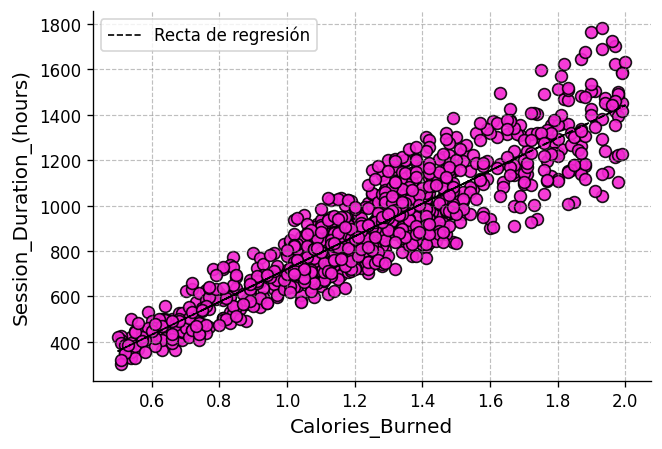

In [8]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Calories_Burned', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Session_Duration_(hours)', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

La recta de regresión ajustada coincide clramente con l tendencia positiva que muestra las observaciones a mayor cantidad de calorias quemadas, mayor es la duracion de la sesion.

In [9]:
modelo.conf_int(alpha=0.05)

,0,1
const,-28.738459,25.845542
Session_Duration_(hours),700.830270,742.741762


La interción tiene un intervalo de confianza del 95% de $[-28.73,25.84]$. Esto significa que se tiene un nivel de confianza de 95% en que la duracion base de la secion cuando no se queman calorias se encuentra en ese grupo. Por otra parte, según el intervalo de confianza de la pendiente, se espera que un estudiante gane entre 700.83 y 742.74 puntos en su índice de desempeño por cada hora de estudio. Esto con una confianza del 95%.


In [10]:
residuales = modelo.resid

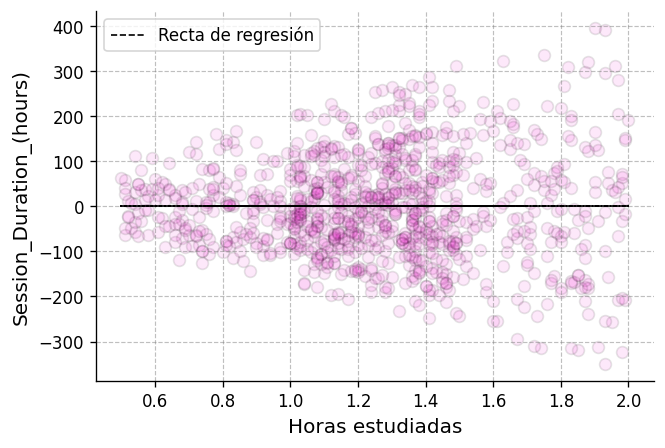

In [11]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.1,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas estudiadas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Session_Duration_(hours)', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Los residuales parecen respaldar la adecuación de la tendencia lineal: se distribuyen de forma aleatoria alrededor de la recta cero sin mostrar patrones curvos marcados. Se observa una mayor concentración de puntos cerca de la línea central y menor frecuencia en los extremos, lo que sugiere un comportamiento cercano a la normalidad.

valor-p (Shapiro) = 0.003841645423152361


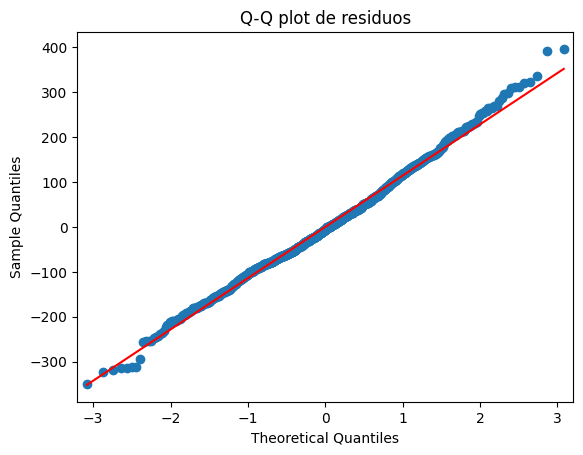

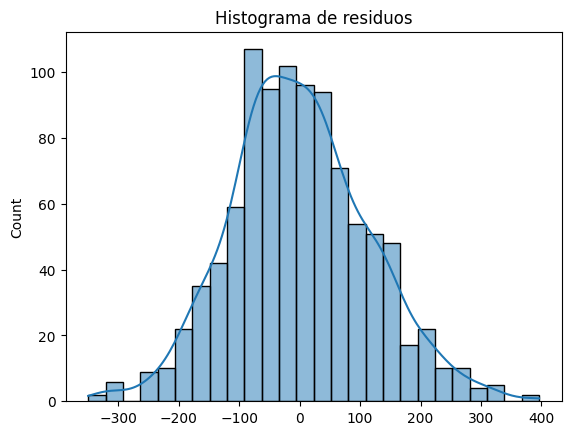

In [12]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Según el histograma y el gráfico cuantil-cuantil (Q-Q) de los residuos, se observa que estos siguen una forma muy cercana a la distribución normal teórica, por lo que cumplen con este supuesto estadístico.


In [13]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
residuales = modelo.resid
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [14]:
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal=ols("Calories_Burned~Q('Session_Duration_(hours)')", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Q('Session_Duration_(hours)'),1.0,5.958764e+07,5.958764e+07,4568.674447,0.0
Residual,971.0,1.266442e+07,1.304265e+04,NaN,NaN
